## Import Required Libraries

In [50]:
import warnings
warnings.filterwarnings('ignore')

#import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
#import xgBoost as xgb
from pandas.plotting import scatter_matrix

In [51]:
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.linear_model import ElasticNet,Lasso,LinearRegression,Ridge
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [52]:
#Reading the dataset into a dataframe

In [53]:
Sales_df = pd.read_csv('Advertisement (2).csv')

In [54]:
Sales_df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [55]:
#Data Preprocessing

In [56]:
Sales_df.drop(['Unnamed: 0'],axis=1,inplace=True)
Sales_df.head(2)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4


In [57]:
#Checking the missing value

In [58]:
Sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


#### The advertisment dataset does not have any missing values.

In [59]:
Sales_df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


#### Based on the above output it shows that most of the spends done on TV.

In [60]:
Sales_df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [61]:
Sales_df.duplicated().sum() # Checking the duplicate value

0

## Train Test Split

In [62]:
train_df,test_df = train_test_split(Sales_df,train_size = 0.75,random_state =1)

In [63]:
train_df.head()

,TV,Radio,Newspaper,Sales
98,289.7,42.3,51.2,25.4
123,123.1,34.6,12.4,15.2
119,19.4,16.0,22.3,6.6
53,182.6,46.2,58.7,21.2
33,265.6,20.0,0.3,17.4


In [64]:
test_df.head()

,TV,Radio,Newspaper,Sales
58,210.8,49.6,37.7,23.8
40,202.5,22.3,31.6,16.6
34,95.7,1.4,7.4,9.5
102,280.2,10.1,21.4,14.8
184,253.8,21.3,30.0,17.6


In [65]:
#Using Scatter Metircs plot

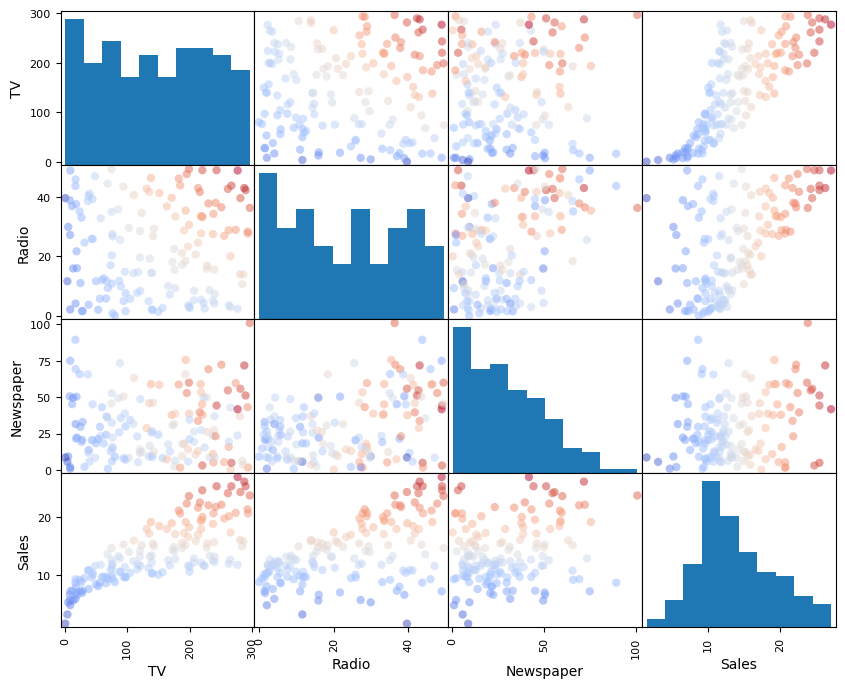

In [66]:
scatter_matrix(train_df,diagonal="hist",marker="o",c=train_df['Sales'],cmap='coolwarm',figsize =(10,8))
plt.show()

In [67]:
# Using boxplot to see the distribution of each function

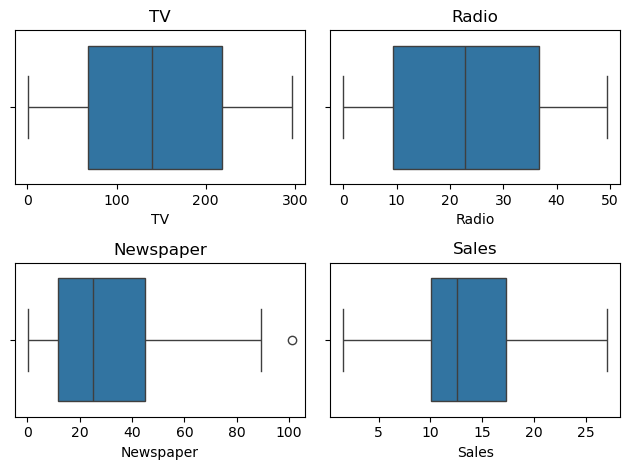

In [68]:
plt.figure()
for col in train_df.select_dtypes(include=['number']).columns:
    plt.subplot(2,2,train_df.columns.get_loc(col)+1)
    sns.boxplot(x=train_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [69]:
# Using displot to see the distribution of each feature

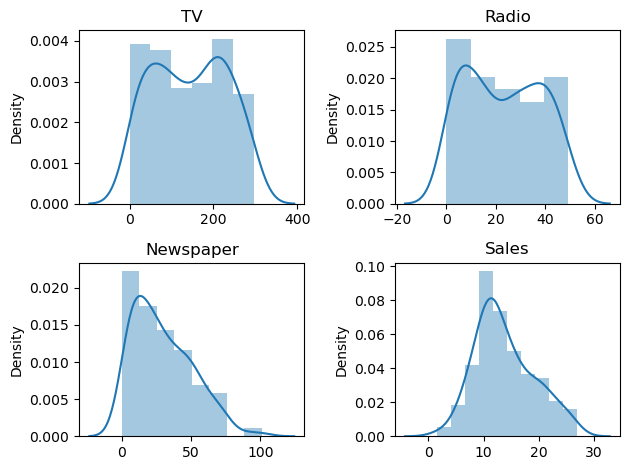

In [70]:
plt.figure()
for col in train_df.select_dtypes(include=['number']).columns:
    plt.subplot(2,2,train_df.columns.get_loc(col)+1)
    sns.distplot(x=train_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [71]:
# Using heatmap to see the relationships

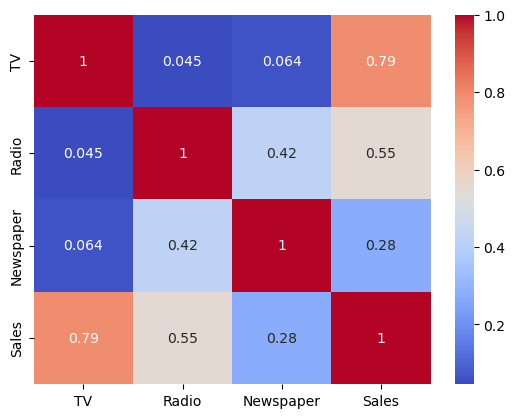

In [72]:
sns.heatmap(train_df.corr(),annot =True,cmap="coolwarm")
plt.show()

### Splitting dependent and Independent Variable

In [73]:
raw_x_train = train_df.drop(['Sales'],axis=1)
raw_y_train= train_df['Sales']
raw_x_test = test_df.drop(['Sales'],axis=1)
raw_y_test = test_df['Sales']

from math import sqrt

### Linear Regression Model

In [88]:
Testing_Score ={}
for L_model in [LinearRegression(),Ridge(),Lasso(),ElasticNet()]:
    model = L_model
    model.fit(raw_x_train,raw_y_train)
    model_predict_train = model.predict(raw_x_train)
    model_predict_test =model.predict(raw_x_test)
            
    mse_train = mean_squared_error(raw_y_train,model_predict_train)
    mse_test = mean_squared_error(raw_y_test,model_predict_test)
    r2s_train = r2_score(raw_y_train,model_predict_train)
    r2s_test = r2_score(raw_y_test,model_predict_test)
    print(f"Accuracy scores for {model} on raw data")
    print("*"*50)
    print("Mean Square Error socre of training:",mse_train)
    print("Mean Square Error socre of testing:",mse_test)
    print("-"*50)
    print("Root Mean Square Error socre of training:",sqrt(mse_train))
    print("Root Mean Square Error socre of testing:",sqrt(mse_test))
    print("-"*50)
    print("R2 Score of training:",r2s_train)
    print("R2 Score of testing:",r2s_test)
    print("*"*50)
    Testing_Score[model.__class__.__name__] = r2s_test

print("\nSummary of Testing R² Scores:")
print(Testing_Score)

Accuracy scores for LinearRegression() on raw data
**************************************************
Mean Square Error socre of training: 3.0867913468291346
Mean Square Error socre of testing: 1.9730456202283384
--------------------------------------------------
Root Mean Square Error socre of training: 1.7569266765659672
Root Mean Square Error socre of testing: 1.4046514230328955
--------------------------------------------------
R2 Score of training: 0.890307557755665
R2 Score of testing: 0.9156213613792232
**************************************************
Accuracy scores for Ridge() on raw data
**************************************************
Mean Square Error socre of training: 3.086791354304747
Mean Square Error socre of testing: 1.9731360610267676
--------------------------------------------------
Root Mean Square Error socre of training: 1.7569266786934357
Root Mean Square Error socre of testing: 1.4046836159885854
--------------------------------------------------
R2 Score 

In [83]:
for L_model in ['LinearRegression()','Ridge()','Lasso()','ElasticNet()']:
    print(L_model)

LinearRegression()
Ridge()
Lasso()
ElasticNet()
